In [8]:
import numpy as np
import trackpy as tp
import matplotlib.pyplot as plt
import zarr

#beads = np.load("/Volumes/data/Sasaki/backup_git/MTCargo_analysis/experiment/20251226/MC00MT001/beads.npy")
za = zarr.open_array("/mnt/e/Sasaki/MTsingleBeads/20260122/exp002_crop/beads.zarr", read_only=True)
beads = za[:, :, :]
output = "/mnt/e/Sasaki/MTsingleBeads/20260122/exp002_crop" #"/Volumes/data/Sasaki/backup_git/MTCargo_analysis/experiment/20251225/MC03MT"
output2 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20260122/exp002"

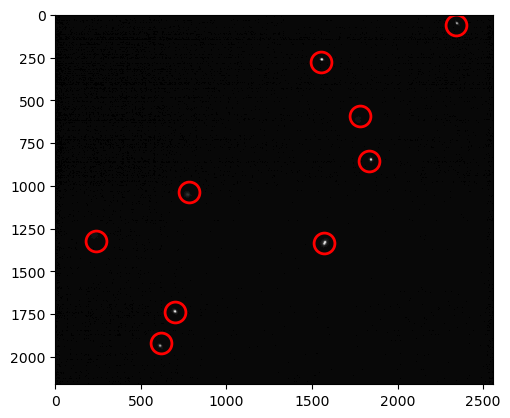

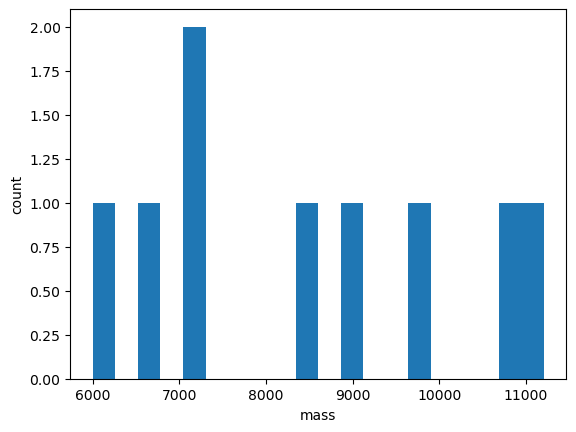

In [12]:
diameter = 1.18*10
scale = 0.11
time_inerval = 4 #timescle

pxdiameter =int(diameter/scale)
if pxdiameter % 2 ==0:
    pxdiameter = pxdiameter + 1

minmass = 1
threshold = 0

f = tp.locate(beads[0], pxdiameter, minmass = minmass, threshold=threshold)
tp.annotate(f, beads[0])

fig, ax = plt.subplots()
ax.hist(f['mass'], bins=20)
# Optionally, label the axes.
ax.set(xlabel='mass', ylabel='count');

#tp.subpx_bias(f)

In [13]:
f = tp.batch(beads, pxdiameter, minmass = minmass, threshold=threshold)

Frame 604: 8 features


In [24]:
cargo_velocity = 1.0 #大体の輸送速度（trackingのdistanceを計測するために使うので大体でいい）
distance = int(cargo_velocity * time_inerval / scale)

tracks = tp.link(f, distance, memory=100)
t1 = tp.filter_stubs(tracks, 100/time_inerval)

Frame 604: 8 trajectories present.


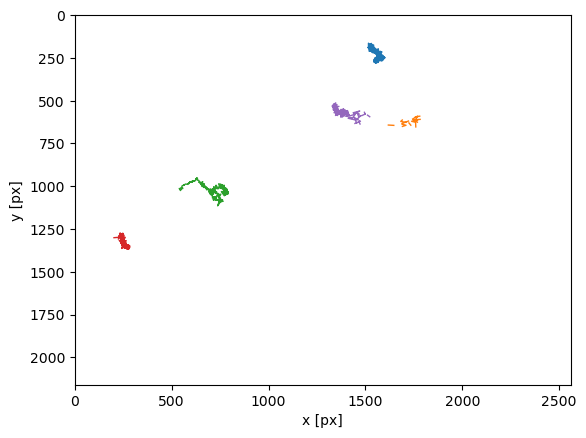

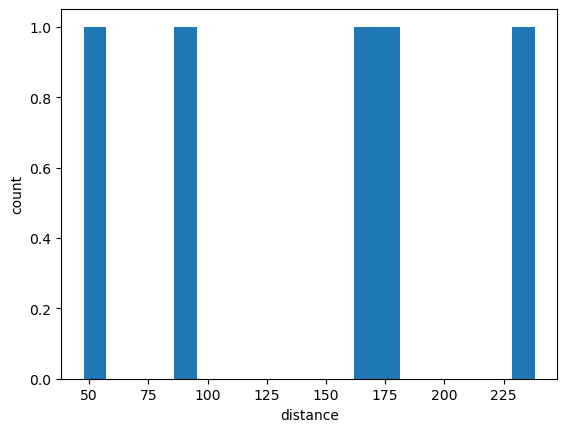

In [25]:
threshold = 40
import os
import sys
sys.path.append(os.path.abspath(".."))
from libs import remove_fixed as rf 

t2 = rf.remove_fixed(t1, threshold)

plt.figure()
plt.xlim((0, 2560))
plt.ylim((0, 2160))
tp.plot_traj(t2);

tracks_dist2 = rf.cal_dis(t2)

fig, ax = plt.subplots()
ax.hist(tracks_dist2["distance"], bins=20)

# Optionally, label the axes.
ax.set(xlabel='distance', ylabel='count');
os.makedirs(output, exist_ok=True)
#os.makedirs(output2, exist_ok=True)
t2.to_csv(f"{output}/beads_tracks.csv", index=False)
#t2.to_csv(f"{output2}/beads_tracks.csv", index=False)